# Supplemental Figure 4e-g: 
Graphical representation for the impact of antigen concentration choice on the selection coefficient for the antigen capture model (4e). 

Graphical representations for the impact of antigen and polyspecificity reagents concentrations on the selection coefficient for the competitive capture model (4f).

Graphical representation (contour plot) showing non-additive effects on the competitive capture selection coefficient for different concentration choices (4g). 

For a full explanation of these figures, please see Methods in Tharp et al, 2026.

done


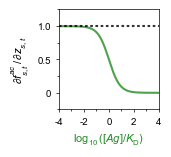

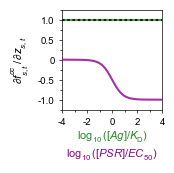

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'


COLOR_EXPR  = '#000000'
COLOR_AFF   = '#228B22'
COLOR_PSR   = '#8b008b'

CANVAS_W = 1
CANVAS_H = 1
LEFT, RIGHT, TOP = 0.60, 0.15, 0.15
BOT_A = 0.45   
BOT_B = 0.80   

N = 800

x_major_log = [-4, -2, 0, 2, 4]
x_minor_log = [-3, -1, 1, 3]

# Supplemental Figure 4e: Impact of antigen concentration choice on the selection coefficient for the antigen capture model
## Change in fitness with respect to expression and affinity (both in log10 space)
log_r = np.linspace(-4, 4, N)
r     = 10**log_r
c_expr_1 = np.ones_like(r)
c_aff_1  = 1.0 / (1.0 + r)

fw1 = LEFT + CANVAS_W + RIGHT
fh1 = BOT_A + CANVAS_H + TOP
fig1, ax1 = plt.subplots(figsize=(fw1, fh1))
fig1.subplots_adjust(left=LEFT/fw1, right=1-RIGHT/fw1,
                     bottom=BOT_A/fh1, top=1-TOP/fh1)

ax1.plot(log_r, c_expr_1, color=COLOR_EXPR, lw=1.5, ls=(0, (1.25,1.25)), zorder=10, alpha = 0.8)
ax1.plot(log_r, c_aff_1,  color=COLOR_AFF,  lw=1.5, alpha = 0.8, zorder=9)

ax1.set_xlim([-4, 4])
ax1.set_ylim([-0.25, 1.25])
ax1.set_xticks(x_major_log)
ax1.set_xticks(x_minor_log, minor=True)
ax1.set_xticklabels([str(x) for x in x_major_log], fontsize=7)
ax1.set_yticks([0, 0.5, 1.0])
ax1.yaxis.set_minor_locator(MultipleLocator(0.25))
ax1.set_yticklabels(['0', '0.5', '1.0'], fontsize=7)

ax1.set_xlabel(r'$\log_{10}([Ag]/K_{\mathrm{D}})$', fontsize=8, color=COLOR_AFF)
ax1.set_ylabel(r'$\partial f^{ac}_{s,t} \,/\, \partial z_{s,t}$', fontsize=8)

ax1.tick_params(which='major', width=0.5, length=2.0, direction='out')
ax1.tick_params(which='minor', width=0.5, length=1.5, direction='out')
for sp in ax1.spines.values():
    sp.set_linewidth(0.5)

fig1.savefig('S_Figure_4e.pdf', dpi=2000, bbox_inches='tight',transparent=True)
fig1.savefig('S_Figure_4e.png', dpi=2000, bbox_inches='tight',transparent=True)

# Supplemental Figure 4f: Impact of antigen concentration and polyspecificity reagent choice on the selection coefficient for the competitive capture model
## Change in fitness with respect to expression, affinity, and polyspecificity (all partial derivatives in log10 space)

log_x = np.linspace(-4, 4, N)
x     = 10**log_x

u_high = 1e10
r_low  = 1e-10

c_expr_2 = np.ones_like(x)
c_aff_2  = (1.0 + u_high) / (1.0 + x + u_high)
c_psr_2  = -x / (1.0 + r_low + x)

fw2 = LEFT + CANVAS_W + RIGHT
fh2 = BOT_B + CANVAS_H + TOP
fig2, ax2 = plt.subplots(figsize=(fw2, fh2))
fig2.subplots_adjust(left=LEFT/fw2, right=1-RIGHT/fw2,
                     bottom=BOT_B/fh2, top=1-TOP/fh2)

ax2.plot(log_x, c_expr_2, color=COLOR_EXPR, lw=1.5,   ls=(0, (1.25,1.25)), zorder=10, alpha=0.8)
ax2.plot(log_x, c_aff_2,  color=COLOR_AFF,  lw=1.5,   zorder=9, alpha=0.8)
ax2.plot(log_x, c_psr_2,  color=COLOR_PSR,  lw=1.5,   zorder=8, alpha=0.8)

ax2.set_xlim([-4, 4])
ax2.set_ylim([-1.25, 1.25])
ax2.set_xticks(x_major_log)
ax2.set_xticks(x_minor_log, minor=True)
ax2.set_xticklabels([str(x) for x in x_major_log], fontsize=7, color='k')
ax2.set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
ax2.yaxis.set_minor_locator(MultipleLocator(0.25))
ax2.set_yticklabels(['-1.0', '-0.5', '0', '0.5', '1.0'], fontsize=7)

ax2.set_ylabel(r'$\partial f^{cc}_{s,t} \,/\, \partial z_{s,t}$', fontsize=8)

ax2.set_xlabel('')
ax2.text(0.5, -0.20, r'$\log_{10}([Ag]/K_{\mathrm{D}})$',
         transform=ax2.transAxes, ha='center', va='top', fontsize=8, color=COLOR_AFF)
ax2.text(0.5, -0.38, r'$\log_{10}([PSR]/\mathit{EC}_{\mathrm{50}})$',
         transform=ax2.transAxes, ha='center', va='top', fontsize=8, color=COLOR_PSR)

ax2.tick_params(which='major', width=0.5, length=2.0, direction='out')
ax2.tick_params(which='minor', width=0.5, length=1.5, direction='out')

ax2.spines['top'].set_linewidth(0.5)
ax2.spines['right'].set_linewidth(0.5)
for sp in ax2.spines.values():
    sp.set_linewidth(0.5)

fig2.savefig('S_Figure_4f.pdf', dpi=2000, bbox_inches='tight',transparent=True)
fig2.savefig('S_Figure_4f.png', dpi=2000, bbox_inches='tight',transparent=True)

print("done")

done


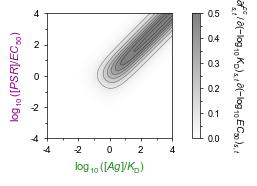

In [2]:
matplotlib.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

# Supplemental Figure 4g: Non-additivity of antigen concentration and polyspecificity reagent choice on the selection coefficient for the competitive capture model
## The more dense the contour is, the less linear the interaction is between the concentration choices

CANVAS_W = 1.25
CANVAS_H = 1.25
LEFT   = 0.55
RIGHT  = 0.15
BOT    = 0.50
TOP    = 0.15
CB_GAP = 0.2
CB_W   = 0.075
CB_H   = 1.25

fw = LEFT + CANVAS_W + CB_GAP + CB_W + RIGHT
fh = BOT  + CANVAS_H + TOP

fig, ax = plt.subplots(figsize=(fw, fh))
fig.subplots_adjust(
    left   = LEFT / fw,
    right  = (LEFT + CANVAS_W) / fw,
    bottom = BOT  / fh,
    top    = (BOT + CANVAS_H) / fh,
)

log_r = np.linspace(-4, 4, 800)
log_u = np.linspace(-4, 4, 800)
X, Y  = np.meshgrid(log_r, log_u)
R, U  = 10**X, 10**Y

mixed = np.log(10) * (R * U) / (1.0 + R + U)**2

cmap_wr = LinearSegmentedColormap.from_list('wr', ['white', 'gray'])

cf = ax.contourf(log_r, log_u, mixed,
                 levels=np.linspace(0, 0.5, 200),
                 cmap=cmap_wr,
                 extend='max')
ax.contour(log_r, log_u, mixed, levels=8, colors='k', linewidths=0.4, alpha=0.5)

ax.set_xlim([-4, 4]); ax.set_ylim([-4, 4])
ax.set_xticks([-4,-2,0,2,4]); ax.set_xticks([-3,-1,1,3], minor=True)
ax.set_yticks([-4,-2,0,2,4]); ax.set_yticks([-3,-1,1,3], minor=True)
ax.set_xticklabels(['-4','-2','0','2','4'], fontsize=7)
ax.set_yticklabels(['-4','-2','0','2','4'], fontsize=7)
ax.tick_params(which='major', width=0.5, length=2.0, direction='out')
ax.tick_params(which='minor', width=0.5, length=1.5, direction='out')
ax.set_xlabel(r'$\log_{10}([Ag]/K_{\mathrm{D}})$', fontsize=8, color='#228B22')
ax.set_ylabel(r'$\log_{10}([PSR]/\mathit{EC}_{\mathrm{50}})$', fontsize=8, color='#8b008b')
for sp in ax.spines.values():
    sp.set_color('k')
    sp.set_linewidth(0.5)

cb_bottom = BOT + (CANVAS_H - CB_H) / 2
cax = fig.add_axes([
    (LEFT + CANVAS_W + CB_GAP) / fw,
    cb_bottom / fh,
    CB_W / fw,
    CB_H / fh,
])
cb = fig.colorbar(cf, cax=cax, extendfrac=0)

cb.set_ticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
cb.ax.yaxis.set_minor_locator(MultipleLocator(0.05))
cb.ax.tick_params(which='major', labelsize=6.5, width=0.5, length=2)
cb.ax.tick_params(which='minor', width=0.5, length=1.5)
cb.outline.set_linewidth(0.5)

cb.set_label(
    r'$\partial f^{cc}_{s,t} \,/\, \partial(-\log_{10} K_{\mathrm{D}})_{s,t}\,\partial(-\log_{10} \mathit{EC}_{\mathrm{50}})_{s,t}$',
    fontsize=7, rotation=270, labelpad=20
)

fig.savefig('S_Figure_4g.pdf', dpi=2000, bbox_inches='tight',transparent=True)
fig.savefig('S_Figure_4g.png', dpi=2000, bbox_inches='tight',transparent=True)
print("done")